# **Task 11: Advanced Supervised ML Algorithms & Housing Price Prediction**

## **1. Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

## **2. Load Housing Dataset**

In [2]:
housing = fetch_california_housing()

X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target)

print(X.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


## **3. Data Inspection**



In [3]:
X.info()
X.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [4]:
X.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0


## **4. Train Test Split**

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## **5. Linear Regression Model**

In [6]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression R2:", lr_r2)

Linear Regression RMSE: 0.7455813830127764
Linear Regression R2: 0.5757877060324508


### **Plot prediction vs actual**

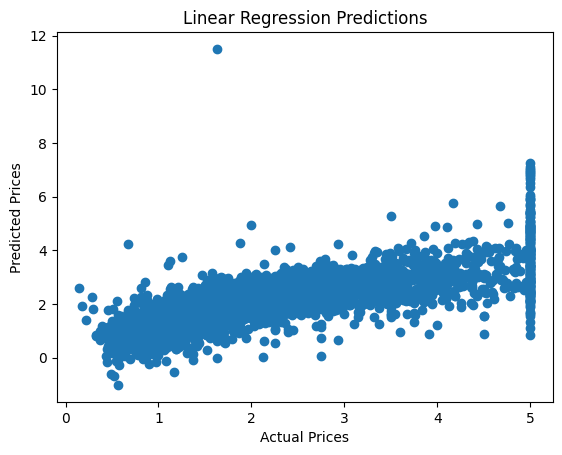

In [7]:
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Linear Regression Predictions")
plt.show()

## **6. Decision Tree Model**

In [8]:
dt = DecisionTreeRegressor(max_depth=5)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
dt_r2 = r2_score(y_test, y_pred_dt)

print("Decision Tree RMSE:", dt_rmse)
print("Decision Tree R2:", dt_r2)

Decision Tree RMSE: 0.7242338143386247
Decision Tree R2: 0.5997321244428706


## **7. Random Forest Regressor**

In [9]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2:", rf_r2)

Random Forest RMSE: 0.5053399773665033
Random Forest R2: 0.8051230593157366


## **8. Support Vector Machine**

In [10]:
svm = SVR(kernel="rbf")

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

svm_rmse = np.sqrt(mean_squared_error(y_test, y_pred_svm))
svm_r2 = r2_score(y_test, y_pred_svm)

print("SVM RMSE:", svm_rmse)
print("SVM R2:", svm_r2)

SVM RMSE: 1.1541280440812771
SVM R2: -0.01648536010717372


## **9. Boosting Algorithms**

### **AdaBoost**

In [11]:
ada = AdaBoostRegressor(n_estimators=100)

ada.fit(X_train, y_train)

y_pred_ada = ada.predict(X_test)

ada_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ada))
ada_r2 = r2_score(y_test, y_pred_ada)

print("AdaBoost RMSE:", ada_rmse)
print("AdaBoost R2:", ada_r2)

AdaBoost RMSE: 0.9037023806155315
AdaBoost R2: 0.37677625360405254


### **Gradient Boosting**

In [12]:
gb = GradientBoostingRegressor()

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_r2 = r2_score(y_test, y_pred_gb)

print("Gradient Boosting RMSE:", gb_rmse)
print("Gradient Boosting R2:", gb_r2)

Gradient Boosting RMSE: 0.5422903000931637
Gradient Boosting R2: 0.7755824521517651


## **10. Model Comparison Table**

In [13]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "AdaBoost",
        "Gradient Boosting"
    ],
    "RMSE": [
        lr_rmse,
        dt_rmse,
        rf_rmse,
        svm_rmse,
        ada_rmse,
        gb_rmse
    ],
    "R2 Score": [
        lr_r2,
        dt_r2,
        rf_r2,
        svm_r2,
        ada_r2,
        gb_r2
    ]
})

results

,Model,RMSE,R2 Score
0,Linear Regression,0.745581,0.575788
1,Decision Tree,0.724234,0.599732
2,Random Forest,0.505340,0.805123
3,SVM,1.154128,-0.016485
4,AdaBoost,0.903702,0.376776
5,Gradient Boosting,0.542290,0.775582


### **Plot comparison**

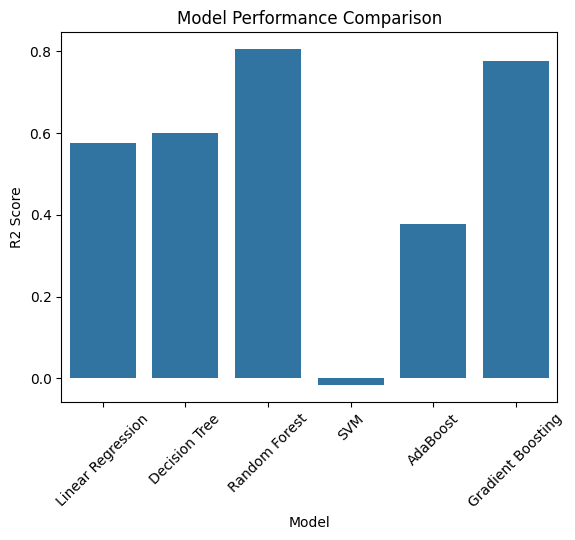

In [14]:
sns.barplot(x="Model", y="R2 Score", data=results)
plt.xticks(rotation=45)
plt.title("Model Performance Comparison")
plt.show()

## **11. Example Prediction**

In [15]:
sample_house = X_test.iloc[0].values.reshape(1,-1)

predicted_price = rf.predict(sample_house)

print("Predicted house price:", predicted_price)

Predicted house price: [0.5095]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


## **12. Hyperparameter Tuning Example**

In [16]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators":[50,100],
    "max_depth":[5,10]
}

grid = GridSearchCV(RandomForestRegressor(), param_grid, cv=3)

grid.fit(X_train,y_train)

print(grid.best_params_)

{'max_depth': 10, 'n_estimators': 100}


## **13. Conclusion**

Multiple machine learning models were trained to predict housing prices.

Random Forest and Gradient Boosting produced higher accuracy compared to Linear Regression.

Tree based models performed better because they capture non linear relationships in data.